In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
def calculate_vrL(Tr):
    """Вычисление vrL"""
    term = 1 - 32*Tr/27
    if term < 0:
        return np.nan
    return (9/(16*Tr)) * (1 - np.sqrt(term))

def calculate_vrG(vrL):
    """Вычисление vrG"""
    if 3*vrL - 1 == 0:
        return np.nan
    return (1/3) * (3*vrL - 1) * np.exp(1 + 3*vrL/(3*vrL - 1))

def calculate_Pr(Tr, vrG, vrL):
    """Вычисление приведенного давления"""
    if vrG - vrL == 0 or 3*vrG - 1 <= 0 or 3*vrL - 1 <= 0 or vrL*vrG == 0:
        return np.nan
    term1 = (8*Tr) / (3*(vrG - vrL)) * np.log((3*vrG - 1)/(3*vrL - 1))
    term2 = 3 / (vrL * vrG)
    return term1 - term2

def vdw_pressure(vr, Tr):
    """Уравнение Ван дер Ваальса для приведенного давления"""
    return (8*Tr)/(3*vr - 1) - 3/(vr**2)

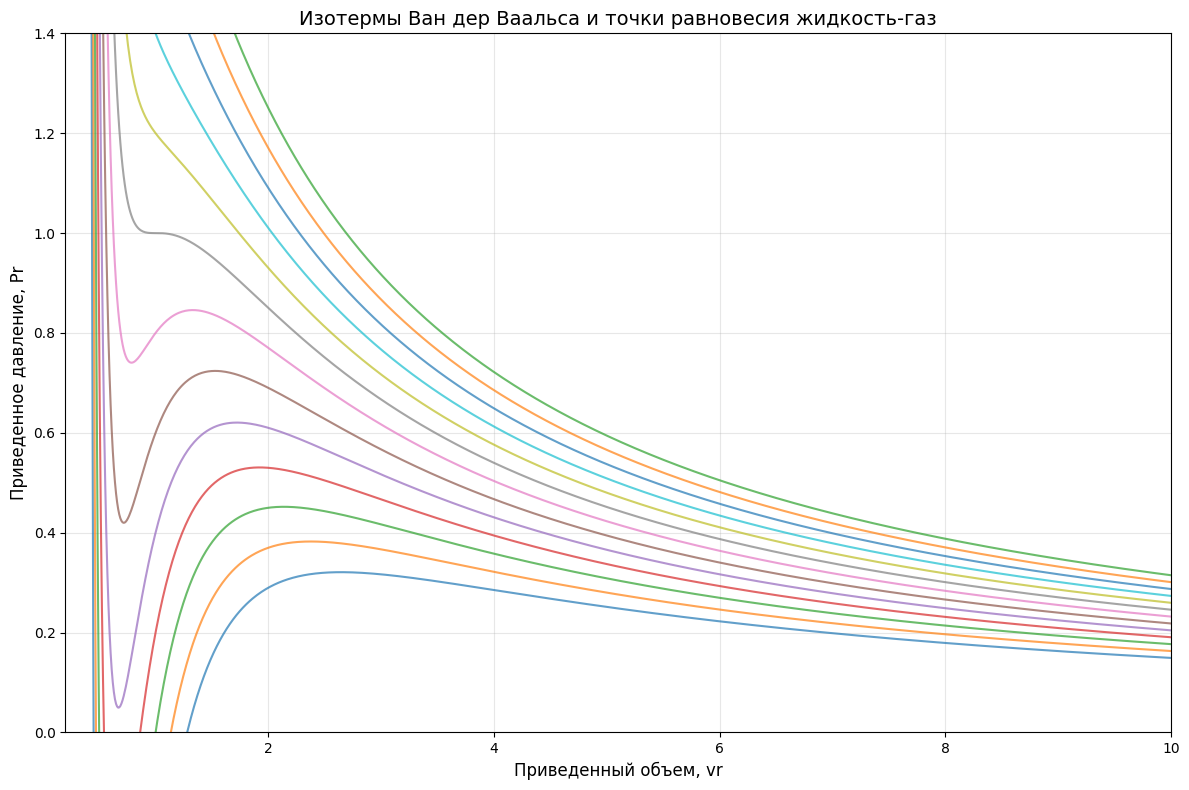

In [13]:
# Вычисляем точки равновесия
temperatures = np.arange(0.65, 1.3, 0.05)
equilibrium_points = []

for Tr in temperatures:
    vrL = calculate_vrL(Tr)
    if not np.isnan(vrL):
        vrG = calculate_vrG(vrL)
        Pr = calculate_Pr(Tr, vrG, vrL)
        if not np.isnan(Pr):
            equilibrium_points.append({
                'Tr': Tr,
                'vrL': vrL,
                'vrG': vrG,
                'Pr': Pr
            })

# Создаем график
plt.figure(figsize=(12, 8))

# Строим изотермы Ван дер Ваальса
vr_range = np.linspace(0.4, 10, 1000)
colors = plt.cm.viridis(np.linspace(0, 1, len(equilibrium_points)))

for i, point in enumerate(equilibrium_points):
    Tr = point['Tr']
    
    # Вычисляем изотерму
    Pr_isotherm = []
    vr_valid = []
    
    for vr in vr_range:
        if 3*vr - 1 > 0:  # Избегаем особенности при vr = 1/3
            Pr_calc = vdw_pressure(vr, Tr)
            if Pr_calc > 0 and Pr_calc < 2:  # Ограничиваем диапазон давлений
                Pr_isotherm.append(Pr_calc)
                vr_valid.append(vr)
    
    
for t in temperatures:
    # Строим изотерму
    plt.plot(vr_range, vdw_pressure(vr_range, t), alpha=0.7, label='Изотерма', linewidth=1.5)
             
plt.xlabel('Приведенный объем, vr', fontsize=12)
plt.ylabel('Приведенное давление, Pr', fontsize=12)
plt.title('Изотермы Ван дер Ваальса и точки равновесия жидкость-газ', fontsize=14)
plt.grid(True, alpha=0.3)


plt.xlim(0.2, 10)
plt.ylim(0, 1.4)
plt.tight_layout()
plt.show()